In [292]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [241]:
data =pd.read_csv('https://raw.githubusercontent.com/Adrian-Cancino/DataScience/refs/heads/main/Data/titanic3.csv')
data.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [242]:
data['survived'].value_counts()

,count
survived,
0,809
1,500


In [243]:
data['sex'].value_counts()

,count
sex,
male,843
female,466


In [244]:
data[['sex','survived']].groupby('sex').mean()

,survived
sex,
female,0.727468
male,0.190985


In [245]:
data['pclass'].value_counts()

,count
pclass,
3,709
1,323
2,277


In [246]:
data[['pclass','survived']].groupby('pclass').mean()

,survived
pclass,
1,0.619195
2,0.429603
3,0.255289


In [247]:
data.groupby('pclass')['sex'].value_counts().sort_values(ascending=False)

pclass  sex   
3       male      493
        female    216
1       male      179
2       male      171
1       female    144
2       female    106
Name: count, dtype: int64

In [248]:
data[['sibsp','survived']].groupby('sibsp').mean().sort_values(by='survived',ascending=False)

,survived
sibsp,
1,0.510972
2,0.452381
0,0.346801
3,0.300000
4,0.136364
5,0.000000
8,0.000000


In [249]:
data[['parch','survived']].groupby('parch').mean().sort_values(by='survived',ascending=False)

,survived
parch,
3,0.625000
1,0.588235
2,0.504425
0,0.335329
4,0.166667
5,0.166667
6,0.000000
9,0.000000


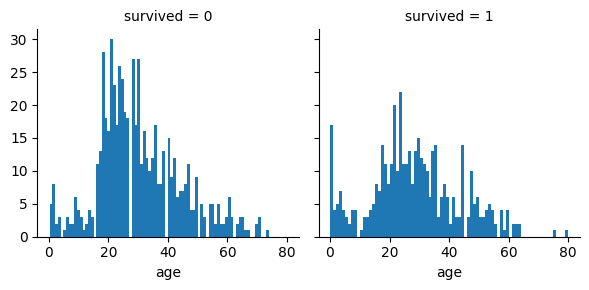

In [250]:
hist_age = sns.FacetGrid(data, col= 'survived')
hist_age.map(plt.hist, 'age', bins = 80)

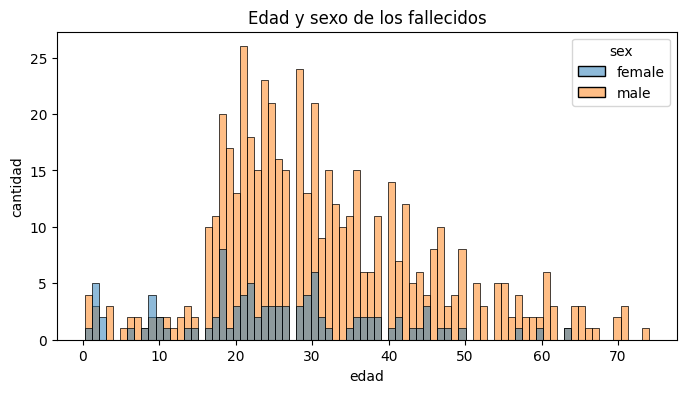

In [251]:
plt.figure(figsize=(8,4))
sns.histplot(data=data[data['survived']==0], x = 'age', hue='sex', bins=80, label = 'no sobrevivió')
plt.xlabel('edad')
plt.ylabel('cantidad')
plt.title('Edad y sexo de los fallecidos')
plt.show()

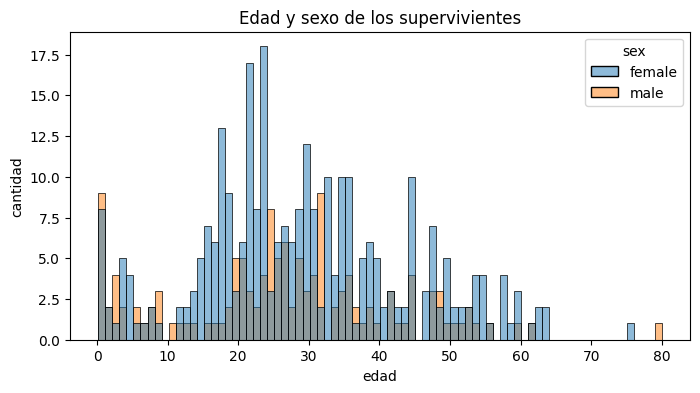

In [252]:
plt.figure(figsize=(8,4))
sns.histplot(data=data[data['survived']==1], x = 'age', hue='sex', bins=80, label = 'sobrevivió')
plt.xlabel('edad')
plt.ylabel('cantidad')
plt.title('Edad y sexo de los supervivientes')
plt.show()

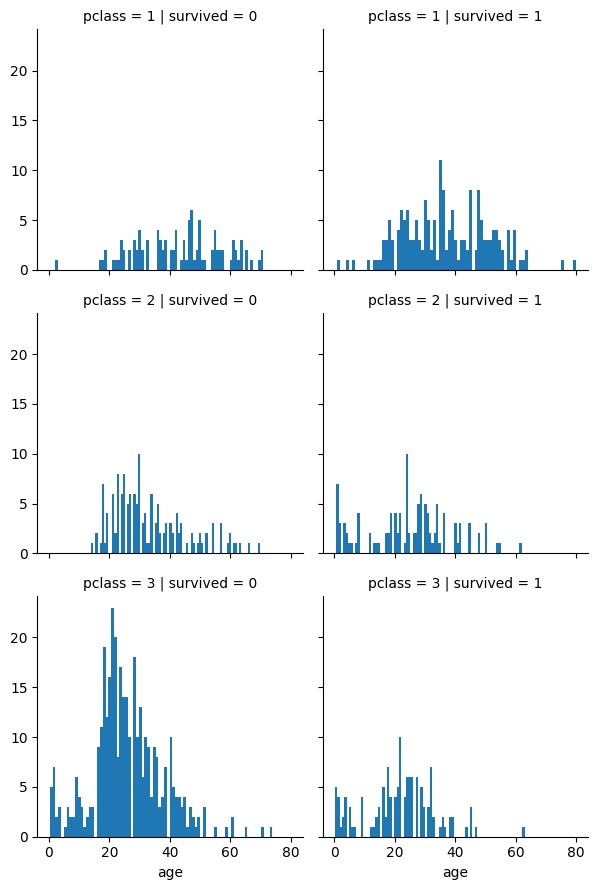

In [253]:
grid_class = sns.FacetGrid(data, col='survived', row='pclass')
grid_class.map(plt.hist,'age', bins=80)
grid_class.add_legend()

Vamos a transformar los datos categoricos a numericos para el ML

In [254]:
#Datos del sexo a valores booleanos
one_hot_encouder = OneHotEncoder()
one = one_hot_encouder.fit_transform(data[['sex']])
one = one.astype(int)
one_hot_encouder_df = pd.DataFrame(one.toarray(), columns=one_hot_encouder.categories_)

In [255]:
#Anadimos el dataframe nuevo al antiguo
data = pd.concat([data, one_hot_encouder_df], axis=1)
#Borramos el sex antiguo
data.drop('sex', axis = 1, inplace = True)

In [256]:
#Eliminamos columnas inutiles
data.drop(['name','ticket','cabin','embarked','boat','body','home.dest'], axis=1, inplace=True)


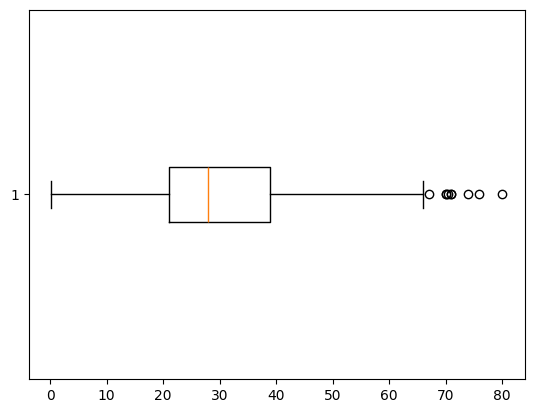

In [257]:
#Nos faltan datos en 'age' veamos un grafico
plt.boxplot(data['age'].dropna(), vert = False)
plt.show()

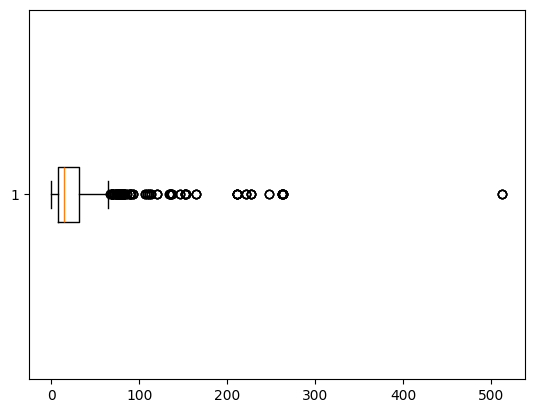

In [258]:
plt.boxplot(data['fare'].dropna(), vert = False)
plt.show()

In [259]:
data_copia = data.copy() #hacemos una copia de los datos para experimentar

In [260]:
data_copia['age'] = data_copia['age'].fillna(data_copia['age'].mean())
data_copia['fare'] = data_copia['fare'].fillna(data_copia['fare'].median())

In [261]:
data_copia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   age        1309 non-null   float64
 3   sibsp      1309 non-null   int64  
 4   parch      1309 non-null   int64  
 5   fare       1309 non-null   float64
 6   (female,)  1309 non-null   int64  
 7   (male,)    1309 non-null   int64  
dtypes: float64(2), int64(6)
memory usage: 81.9 KB


In [262]:
x = data_copia.drop(['survived'], axis =1).values
y = data_copia['survived'].values
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=42)
#Regresion Logistica
log_reg = LogisticRegression(random_state=0, max_iter = 400)
log_reg.fit(x_train,y_train)

LogisticRegression(max_iter=400, random_state=0)

In [263]:
y_pred = log_reg.predict(x_test)

In [264]:
confusion_matrix(y_test, y_pred)

array([[127,  17],
       [ 43,  75]])

Verdaderos positivos 127, Falsos positivos 17, Verdaderos negativos 43, Falsos negativos 73

In [265]:
"""PARA MIMINIZAR USAMOS
   Falsos neg     Recall
   Falsos pos     Precision
   Errores gen    F1"""
print(f"Precision", (precision_score(y_test, y_pred)*100),"%")
print(f"Recall", (recall_score(y_test, y_pred)*100),"%")
print(f"F1", (f1_score(y_test, y_pred)*100),"%")
print(f"Score",round(log_reg.score(x_train,y_train)*100,2),"%")

Precision 81.52173913043478 %
Recall 63.559322033898304 %
F1 71.42857142857143 %
Score 79.47 %


In [266]:
#ARBOL DE DECISIONES
cls = DecisionTreeClassifier(random_state=0)
cls.fit(x_train,y_train)

DecisionTreeClassifier(random_state=0)

In [271]:
y_pred = cls.predict(x_test)
print(f"Predicciones:", y_pred[:10],"Reales:",y_test[:10])

Predicciones: [0 0 0 0 0 0 0 0 0 1] Reales: [0 1 0 0 0 1 0 1 0 1]


In [272]:
confusion_matrix(y_test, y_pred)

array([[123,  21],
       [ 38,  80]])

In [274]:
print(f"Precision", (precision_score(y_test, y_pred)*100),"%")
print(f"Recall", (recall_score(y_test, y_pred)*100),"%")
print(f"F1", (f1_score(y_test, y_pred)*100),"%")
print(f"Score",round(cls.score(x_train,y_train)*100,2),"%")

Precision 79.20792079207921 %
Recall 67.79661016949152 %
F1 73.0593607305936 %
Score 97.04 %


In [286]:
#Bosque aleatorio
rfc = RandomForestClassifier(n_estimators=100,random_state=0)
rfc.fit(x_train,y_train)

RandomForestClassifier(random_state=0)

In [288]:
y_pred = rfc.predict(x_test)
print(f"Predicciones:", y_pred[:10],"Reales:",y_test[:10])

Predicciones: [0 0 0 0 0 0 0 0 0 1] Reales: [0 1 0 0 0 1 0 1 0 1]


In [289]:
confusion_matrix(y_test, y_pred)

array([[125,  19],
       [ 40,  78]])

In [290]:
print(f"Precision", (precision_score(y_test, y_pred)*100),"%")
print(f"Recall", (recall_score(y_test, y_pred)*100),"%")
print(f"F1", (f1_score(y_test, y_pred)*100),"%")
print(f"Score",round(rfc.score(x_train,y_train)*100,2),"%")

Precision 80.41237113402062 %
Recall 66.10169491525424 %
F1 72.55813953488372 %
Score 97.04 %


In [293]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [294]:
y_pred = rfc.predict(x_test)
print(f"Predicciones:", y_pred[:10],"Reales:",y_test[:10])

Predicciones: [0 0 0 0 0 0 0 0 0 1] Reales: [0 1 0 0 0 1 0 1 0 1]


In [295]:
confusion_matrix(y_test, y_pred)

array([[125,  19],
       [ 40,  78]])

In [296]:
print(f"Precision", (precision_score(y_test, y_pred)*100),"%")
print(f"Recall", (recall_score(y_test, y_pred)*100),"%")
print(f"F1", (f1_score(y_test, y_pred)*100),"%")
print(f"Score",round(rfc.score(x_train,y_train)*100,2),"%")

Precision 80.41237113402062 %
Recall 66.10169491525424 %
F1 72.55813953488372 %
Score 97.04 %
